# Proyecto Final · Ceci · Machine Learning

**Clasificación multiclase del tono observado en operativos territoriales de Formosa**

Este notebook acompaña el informe final y está construido para ser reproducible de principio a fin.

- Dataset: sintético
- Registros esperados: 4.180
- Target: `tono_categoria`
- Clases: Amable, Neutral, Resignado, Quejoso, Hostil
- Métrica principal: Macro F1
- Métrica complementaria: Balanced Accuracy
- Split: por `operativo_id`
- Modelo final: XGBoost optimizado con GridSearchCV

> Los resultados son metodológicos y describen el dataset sintético. No deben interpretarse como una medición poblacional real de Formosa.

## 1. Entorno e imports

In [45]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Entorno listo.")

Entorno listo.


## 2. Carga del CSV y validaciones

El notebook busca primero la ruta prevista para GitHub:

`data/consolidado/ceci_formosa.csv`

También admite el nombre original utilizado durante la preparación de la entrega para facilitar la ejecución local.

In [46]:
from pathlib import Path
import pandas as pd

# Funciona si Jupyter arranca desde la raíz
# o desde la carpeta notebooks
CWD = Path.cwd().resolve()

if (CWD / "data" / "consolidado").exists():
    PROJECT_ROOT = CWD
else:
    PROJECT_ROOT = CWD.parent

DATA = (
    PROJECT_ROOT
    / "data"
    / "consolidado"
    / "ceci_formosa.csv"
)

print("Raíz del proyecto:", PROJECT_ROOT)
print("Archivo:", DATA)
print("Existe:", DATA.exists())

if not DATA.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en: {DATA}"
    )

df = pd.read_csv(
    DATA,
    sep=";",
    encoding="utf-8-sig"
)

assert df.shape == (4180, 34)

print("Dimensiones:", df.shape)
print(
    "Registros únicos:",
    df["registro_id"].nunique()
)

print("Dataset cargado correctamente.")

Raíz del proyecto: C:\ceci-proyecto-final
Archivo: C:\ceci-proyecto-final\data\consolidado\ceci_formosa.csv
Existe: True
Dimensiones: (4180, 34)
Registros únicos: 4180
Dataset cargado correctamente.


In [47]:
assert df.shape == (4180, 34), f"Dimensión inesperada: {df.shape}"
assert df["registro_id"].nunique() == 4180
assert df["operativo_id"].nunique() == 142
assert df["localidad_id"].nunique() == 37
assert df["departamento"].nunique() == 9
assert df["relevador_id"].nunique() == 2
assert df["registro_id"].duplicated().sum() == 0

for c in ["P001", "P002", "P003", "P004"]:
    assert df[c].dropna().between(1, 5).all()

assert df["tono_nivel"].dropna().between(1, 10).all()

print("Validaciones estructurales OK.")

Validaciones estructurales OK.


## 3. EDA: estructura, tipos, faltantes y calidad

In [48]:
print(df.info())

resumen_numerico = df[
    ["P001", "P002", "P003", "P004", "tono_nivel",
     "cantidad_tramites", "P006_claridad", "P007_satisfaccion"]
].describe().T

display(resumen_numerico)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4180 entries, 0 to 4179
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   schema_version               4180 non-null   object
 1   formulario_id                4180 non-null   object
 2   formulario_version           4180 non-null   int64 
 3   registro_id                  4180 non-null   object
 4   operativo_id                 4180 non-null   object
 5   punto_operativo_id           4180 non-null   object
 6   punto_operativo              4180 non-null   object
 7   fecha                        4180 non-null   object
 8   hora                         4180 non-null   object
 9   relevador_id                 4180 non-null   object
 10  dispositivo_id               4180 non-null   object
 11  sync_lote_id                 4180 non-null   object
 12  provincia                    4180 non-null   object
 13  departamento                 4180

,count,mean,std,min,25%,50%,75%,max
P001,4180.0,3.436124,1.162131,1.0,3.0,4.0,4.0,5.0
P002,4180.0,3.374402,1.270448,1.0,2.0,3.0,4.0,5.0
P003,4180.0,3.379904,1.296886,1.0,2.0,3.0,5.0,5.0
P004,4180.0,3.410287,1.245942,1.0,3.0,4.0,4.0,5.0
tono_nivel,4180.0,4.078230,2.285205,1.0,2.0,4.0,5.0,10.0
cantidad_tramites,4180.0,1.325120,0.566083,1.0,1.0,1.0,2.0,3.0
P006_claridad,4180.0,3.341866,1.240274,1.0,2.0,3.0,4.0,5.0
P007_satisfaccion,4180.0,3.385646,1.219835,1.0,3.0,3.0,4.0,5.0


In [49]:
faltantes = (
    df.isna()
      .sum()
      .to_frame("faltantes")
      .assign(porcentaje=lambda x: x["faltantes"] / len(df) * 100)
      .sort_values("faltantes", ascending=False)
)

display(faltantes.head(15))

,faltantes,porcentaje
schema_version,0,0.0
formulario_id,0,0.0
formulario_version,0,0.0
registro_id,0,0.0
operativo_id,0,0.0
punto_operativo_id,0,0.0
punto_operativo,0,0.0
fecha,0,0.0
hora,0,0.0
relevador_id,0,0.0


In [50]:
estado_respuesta = df["estado_respuesta"].value_counts()
display(estado_respuesta.to_frame("cantidad"))

assert estado_respuesta.get("completa", 0) == 3564
assert estado_respuesta.get("parcial", 0) == 616

,cantidad
estado_respuesta,
completa,3564
parcial,616


### Lectura del EDA

El dataset posee 4.180 registros y 34 columnas. No existen duplicados en `registro_id`.  
Las preguntas P001-P004 utilizan una escala 1-5, mientras que `tono_nivel` utiliza una escala 1-10.  
El pipeline conservará imputación para tolerar futuros datos reales incompletos.

## 4. Construcción del target y control de data leakage

In [51]:
def crear_target_tono(nivel):
    if nivel in [1, 2]:
        return "Amable"
    if nivel in [3, 4]:
        return "Neutral"
    if nivel in [5, 6]:
        return "Resignado"
    if nivel in [7, 8]:
        return "Quejoso"
    if nivel in [9, 10]:
        return "Hostil"
    return np.nan

df["tono_categoria"] = df["tono_nivel"].apply(crear_target_tono)

orden_tono = ["Amable", "Neutral", "Resignado", "Quejoso", "Hostil"]

target_counts = (
    df["tono_categoria"]
      .value_counts()
      .reindex(orden_tono)
)

display(target_counts.to_frame("cantidad"))

assert target_counts.to_dict() == {
    "Amable": 1105,
    "Neutral": 1664,
    "Resignado": 714,
    "Quejoso": 444,
    "Hostil": 253,
}

,cantidad
tono_categoria,
Amable,1105
Neutral,1664
Resignado,714
Quejoso,444
Hostil,253


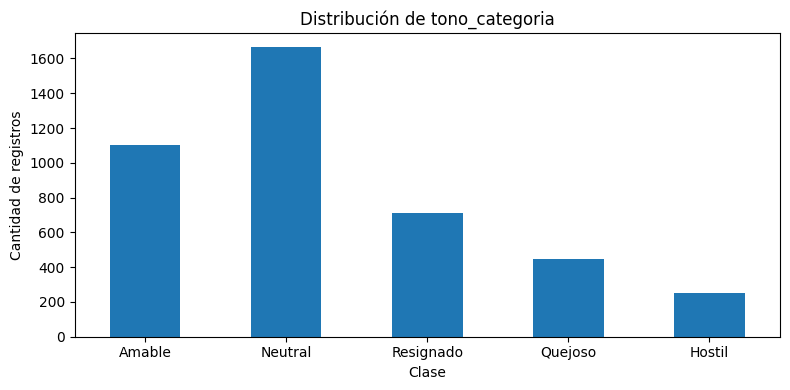

In [52]:
target_counts.plot(kind="bar", figsize=(8, 4))
plt.title("Distribución de tono_categoria")
plt.ylabel("Cantidad de registros")
plt.xlabel("Clase")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
columnas_leakage = ["tono_nivel", "tono_codigo", "tono_categoria"]

print("Variables excluidas por leakage:", columnas_leakage)

Variables excluidas por leakage: ['tono_nivel', 'tono_codigo', 'tono_categoria']


`tono_nivel` se utiliza únicamente para construir la etiqueta. `tono_codigo` expresa la misma observación en forma textual.  
Por lo tanto, ambas variables se excluyen de las características predictoras.

## 5. EDA territorial

In [54]:
df["tono_critico"] = df["tono_categoria"].isin(["Quejoso", "Hostil"])

territorial = (
    df.groupby("departamento")
      .agg(
          encuestas=("registro_id", "nunique"),
          pct_critico=("tono_critico", "mean"),
          satisfaccion_media=("P007_satisfaccion", "mean"),
      )
      .reset_index()
)

territorial["pct_critico"] *= 100

display(
    territorial.sort_values("departamento")
               .style.format({
                   "pct_critico": "{:.1f}%",
                   "satisfaccion_media": "{:.2f}",
               })
)

,departamento,encuestas,pct_critico,satisfaccion_media
0,Bermejo,287,13.9%,3.57
1,Formosa,1290,14.9%,3.46
2,Laishí,197,18.8%,3.27
3,Matacos,143,18.2%,3.49
4,Patiño,622,21.2%,3.26
5,Pilagás,408,14.7%,3.44
6,Pilcomayo,676,16.6%,3.38
7,Pirané,409,18.3%,3.23
8,Ramón Lista,148,15.5%,3.30


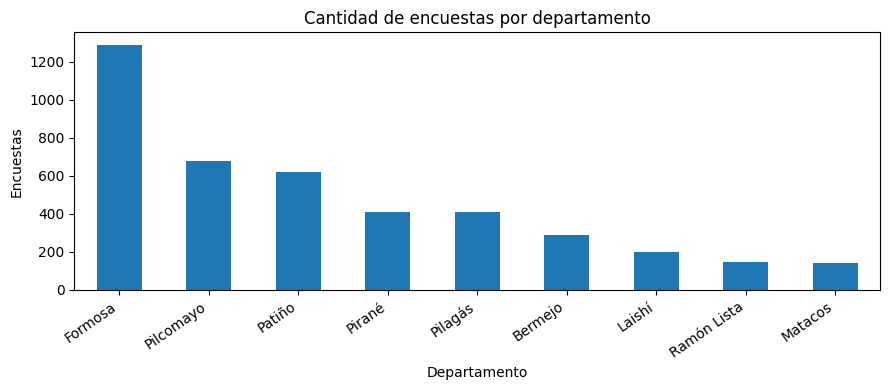

In [55]:
por_depto = df.groupby("departamento").size().sort_values(ascending=False)

por_depto.plot(kind="bar", figsize=(9, 4))
plt.title("Cantidad de encuestas por departamento")
plt.ylabel("Encuestas")
plt.xlabel("Departamento")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [56]:
cobertura_localidad = (
    df.groupby(["departamento", "localidad"])["registro_id"]
      .nunique()
      .sort_values()
)

print("Localidades cubiertas:", len(cobertura_localidad))
print("Mínimo de encuestas por localidad:", cobertura_localidad.min())

assert len(cobertura_localidad) == 37
assert cobertura_localidad.min() == 24

Localidades cubiertas: 37
Mínimo de encuestas por localidad: 24


## 6. Mapa territorial con geometrías oficiales

Raíz del proyecto: C:\ceci-proyecto-final
Usando GeoJSON poligonal local: C:\ceci-proyecto-final\data\geo\departamentos_formosa_poligonos.geojson
Geometrías poligonales: 9
Departamentos reconocidos: ['Bermejo', 'Formosa', 'Laishi', 'Matacos', 'Patiño', 'Pilagás', 'Pilcomayo', 'Pirané', 'Ramón Lista']
Validación territorial OK: 9 departamentos.
Latitud media: -25.051
Corrección horizontal: 0.906


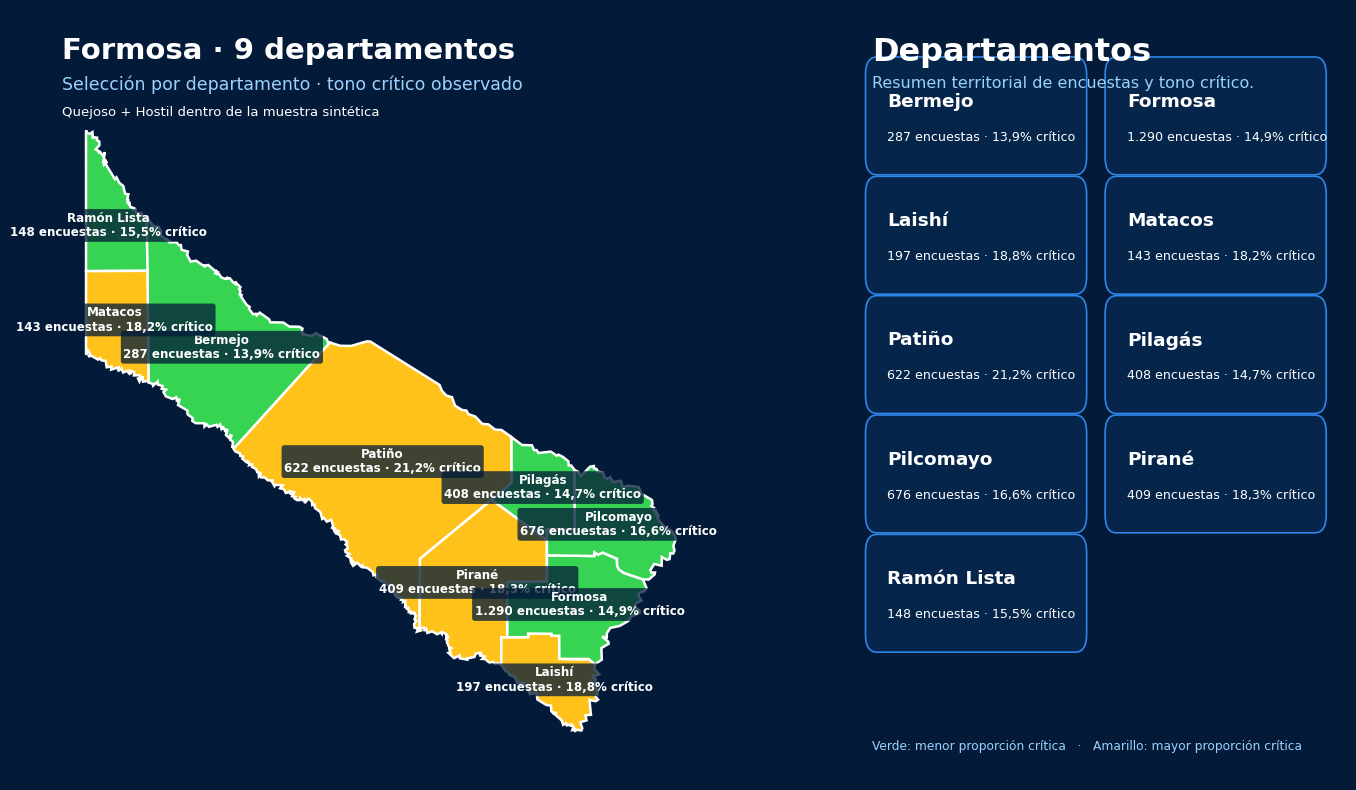


Mapa/dashboard generado correctamente.
PNG: C:\ceci-proyecto-final\outputs\graficos\mapa_formosa_dashboard.png
Resumen: C:\ceci-proyecto-final\outputs\dashboard\resumen_territorial_formosa.csv


In [59]:
from pathlib import Path
import json
import math
import unicodedata

import requests
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, FancyBboxPatch


# ============================================================
# 1. DETECTAR RAÍZ DEL PROYECTO
# ============================================================

CWD = Path.cwd().resolve()

PROJECT_ROOT = None

for base in [CWD, *CWD.parents]:
    if (
        (base / "requirements.txt").exists()
        and (base / "notebooks").exists()
    ):
        PROJECT_ROOT = base
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No se pudo identificar la raíz del proyecto."
    )

print("Raíz del proyecto:", PROJECT_ROOT)


# ============================================================
# 2. CARPETAS
# ============================================================

GEO_DIR = PROJECT_ROOT / "data" / "geo"
OUT_GRAF = PROJECT_ROOT / "outputs" / "graficos"
OUT_DASH = PROJECT_ROOT / "outputs" / "dashboard"

GEO_DIR.mkdir(parents=True, exist_ok=True)
OUT_GRAF.mkdir(parents=True, exist_ok=True)
OUT_DASH.mkdir(parents=True, exist_ok=True)

# Archivo específico para polígonos.
# No reutilizamos el GeoJSON viejo que podía contener Points.
GEO_FILE = GEO_DIR / "departamentos_formosa_poligonos.geojson"


# ============================================================
# 3. FUNCIONES DE NORMALIZACIÓN
# ============================================================

def normalizar(texto):
    texto = str(texto).strip().lower()

    texto = "".join(
        caracter
        for caracter in unicodedata.normalize("NFD", texto)
        if unicodedata.category(caracter) != "Mn"
    )

    return " ".join(texto.split())


def obtener_nombre(props):
    """
    Busca el nombre del departamento contemplando
    distintas variantes de campos del GeoJSON.
    """

    candidatos = [
        "nombre",
        "departamento.nombre",
        "departamento_nombre",
        "FNA",
        "deptos.FNA",
    ]

    for campo in candidatos:
        if campo in props and props[campo] is not None:
            return str(props[campo])

    # Búsqueda adicional
    for clave, valor in props.items():

        clave_min = str(clave).lower()

        if (
            clave_min.endswith("nombre")
            or clave_min.endswith("fna")
        ):
            if valor is not None:
                return str(valor)

    return None


# ============================================================
# 4. VALIDAR / DESCARGAR GEOJSON POLIGONAL
# ============================================================

def geojson_tiene_poligonos(geo):
    if "features" not in geo:
        return False

    tipos = {
        feature.get("geometry", {}).get("type")
        for feature in geo["features"]
    }

    return bool(
        tipos.intersection(
            {"Polygon", "MultiPolygon"}
        )
    )


geojson_fsa = None


# ------------------------------------------------------------
# Si existe un archivo local válido, usarlo
# ------------------------------------------------------------

if GEO_FILE.exists():

    geo_local = json.loads(
        GEO_FILE.read_text(
            encoding="utf-8"
        )
    )

    if geojson_tiene_poligonos(geo_local):

        geojson_fsa = geo_local

        print(
            "Usando GeoJSON poligonal local:",
            GEO_FILE
        )

    else:

        print(
            "El GeoJSON local no contiene polígonos. "
            "Se descargará nuevamente."
        )


# ------------------------------------------------------------
# Descargar base oficial completa si hace falta
# ------------------------------------------------------------

if geojson_fsa is None:

    print(
        "Descargando polígonos oficiales de departamentos..."
    )

    URL_GEO = (
        "https://apis.datos.gob.ar/"
        "georef/api/departamentos.geojson"
    )

    respuesta = requests.get(
        URL_GEO,
        timeout=60
    )

    respuesta.raise_for_status()

    geo_argentina = respuesta.json()

    features_formosa = []


    # --------------------------------------------------------
    # Filtrar Formosa
    # Código provincial INDEC: 34
    # --------------------------------------------------------

    for feature in geo_argentina.get(
        "features",
        []
    ):

        props = feature.get(
            "properties",
            {}
        )

        geometry = feature.get(
            "geometry",
            {}
        )

        tipo_geom = geometry.get(
            "type"
        )

        if tipo_geom not in {
            "Polygon",
            "MultiPolygon"
        }:
            continue


        # Buscar código departamental
        posibles_id = [
            props.get("id"),
            props.get("departamento.id"),
            props.get("departamento_id"),
            props.get("IN1"),
            props.get("deptos.IN1"),
        ]

        dep_id = None

        for valor in posibles_id:
            if valor is not None:
                dep_id = str(valor)
                break


        # Los códigos departamentales de Formosa
        # comienzan con 34.
        if (
            dep_id is not None
            and dep_id.startswith("34")
        ):
            features_formosa.append(
                feature
            )


    geojson_fsa = {
        "type": "FeatureCollection",
        "features": features_formosa,
    }


    if len(features_formosa) != 9:

        raise ValueError(
            "Se esperaban 9 departamentos poligonales "
            f"de Formosa y se encontraron "
            f"{len(features_formosa)}."
        )


    GEO_FILE.write_text(
        json.dumps(
            geojson_fsa,
            ensure_ascii=False
        ),
        encoding="utf-8"
    )

    print(
        "GeoJSON guardado en:",
        GEO_FILE
    )


print(
    "Geometrías poligonales:",
    len(geojson_fsa["features"])
)


# ============================================================
# 5. PREPARAR DATOS TERRITORIALES
# ============================================================

territorial_mapa = territorial.copy()

territorial_mapa["nombre_match"] = (
    territorial_mapa["departamento"]
    .apply(normalizar)
)

datos_lookup = (
    territorial_mapa
    .set_index("nombre_match")
    .to_dict("index")
)


DEPARTAMENTOS_FORMOSA = [
    "Bermejo",
    "Formosa",
    "Laishí",
    "Matacos",
    "Patiño",
    "Pilagás",
    "Pilcomayo",
    "Pirané",
    "Ramón Lista",
]

esperados = {
    normalizar(nombre)
    for nombre in DEPARTAMENTOS_FORMOSA
}


# ============================================================
# 6. VALIDAR DEPARTAMENTOS DEL GEOJSON
# ============================================================

features_validas = []

for feature in geojson_fsa["features"]:

    props = feature.get(
        "properties",
        {}
    )

    nombre = obtener_nombre(
        props
    )

    if nombre is None:
        continue

    match = normalizar(
        nombre
    )

    if match in esperados:

        features_validas.append({
            "nombre": nombre,
            "nombre_match": match,
            "geometry": feature["geometry"],
        })


nombres_geo = {
    feature["nombre_match"]
    for feature in features_validas
}


faltantes_geo = (
    esperados
    - nombres_geo
)

faltantes_csv = (
    esperados
    - set(datos_lookup.keys())
)


if faltantes_geo:
    raise ValueError(
        "Departamentos faltantes en GeoJSON: "
        f"{sorted(faltantes_geo)}"
    )


if faltantes_csv:
    raise ValueError(
        "Departamentos faltantes en CSV: "
        f"{sorted(faltantes_csv)}"
    )


assert len(features_validas) == 9


print(
    "Departamentos reconocidos:",
    sorted(
        feature["nombre"]
        for feature in features_validas
    )
)

print(
    "Validación territorial OK: 9 departamentos."
)


# ============================================================
# 7. EXTRAER POLÍGONOS
# ============================================================

def extraer_poligonos(geometry):

    tipo = geometry["type"]
    coords = geometry["coordinates"]

    if tipo == "Polygon":

        return [
            coords[0]
        ]

    elif tipo == "MultiPolygon":

        return [
            poligono[0]
            for poligono in coords
        ]

    else:

        raise ValueError(
            f"Geometría inesperada: {tipo}"
        )


# ============================================================
# 8. CORRECCIÓN VISUAL DE PROYECCIÓN
# ============================================================

# Matplotlib dibuja longitud y latitud como si un grado
# horizontal midiera lo mismo que uno vertical.
# Aplicamos una corrección equirectangular simple.

todas_latitudes = []
todas_longitudes = []


for feature in features_validas:

    poligonos = extraer_poligonos(
        feature["geometry"]
    )

    for poligono in poligonos:

        todas_longitudes.extend(
            punto[0]
            for punto in poligono
        )

        todas_latitudes.extend(
            punto[1]
            for punto in poligono
        )


lat_media = (
    sum(todas_latitudes)
    / len(todas_latitudes)
)

lon_media = (
    sum(todas_longitudes)
    / len(todas_longitudes)
)

FACTOR_X = math.cos(
    math.radians(
        lat_media
    )
)


print(
    "Latitud media:",
    round(lat_media, 3)
)

print(
    "Corrección horizontal:",
    round(FACTOR_X, 3)
)


def transformar_punto(
    lon,
    lat
):
    """
    Proyección equirectangular local simplificada.
    """

    x = (
        lon - lon_media
    ) * FACTOR_X

    y = (
        lat - lat_media
    )

    return x, y


def transformar_poligono(poligono):

    return [
        transformar_punto(
            lon,
            lat
        )
        for lon, lat in poligono
    ]


# ============================================================
# 9. CENTROIDE APROXIMADO DE POLÍGONO
# ============================================================

def centroide_poligono(
    puntos
):
    """
    Centroide geométrico mediante fórmula del área.
    """

    if len(puntos) < 3:

        xs = [
            p[0]
            for p in puntos
        ]

        ys = [
            p[1]
            for p in puntos
        ]

        return (
            sum(xs) / len(xs),
            sum(ys) / len(ys)
        )


    area = 0
    cx = 0
    cy = 0


    for i in range(
        len(puntos) - 1
    ):

        x0, y0 = puntos[i]
        x1, y1 = puntos[i + 1]

        cruz = (
            x0 * y1
            - x1 * y0
        )

        area += cruz

        cx += (
            x0 + x1
        ) * cruz

        cy += (
            y0 + y1
        ) * cruz


    area *= 0.5


    if abs(area) < 1e-10:

        xs = [
            p[0]
            for p in puntos
        ]

        ys = [
            p[1]
            for p in puntos
        ]

        return (
            sum(xs) / len(xs),
            sum(ys) / len(ys)
        )


    cx /= (
        6 * area
    )

    cy /= (
        6 * area
    )


    return cx, cy


def centro_feature(
    poligonos_transformados
):

    principal = max(
        poligonos_transformados,
        key=lambda p: len(p)
    )

    return centroide_poligono(
        principal
    )


# ============================================================
# 10. PALETA
# ============================================================

FONDO = "#031b39"
PANEL = "#06254a"

BLANCO = "#ffffff"
CELESTE = "#9bd1ff"

AZUL_BORDE = "#2d86e8"

VERDE = "#36d452"
AMARILLO = "#ffc21b"


# Tono crítico:
# Quejoso + Hostil
UMBRAL_CRITICO = 17.5


# ============================================================
# 11. FIGURA
# ============================================================

fig = plt.figure(
    figsize=(18, 10),
    facecolor=FONDO
)


gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[
        1.72,
        1
    ],
    wspace=0.055
)


ax_mapa = fig.add_subplot(
    gs[0, 0]
)

ax_panel = fig.add_subplot(
    gs[0, 1]
)


ax_mapa.set_facecolor(
    FONDO
)

ax_panel.set_facecolor(
    FONDO
)


# ============================================================
# 12. DIBUJAR MAPA
# ============================================================

todos_x = []
todos_y = []

centros = {}


for feature in features_validas:

    match = feature[
        "nombre_match"
    ]

    datos = datos_lookup[
        match
    ]

    porcentaje = float(
        datos["pct_critico"]
    )


    color = (
        AMARILLO
        if porcentaje >= UMBRAL_CRITICO
        else VERDE
    )


    poligonos_originales = (
        extraer_poligonos(
            feature["geometry"]
        )
    )


    poligonos_transformados = []


    for poligono in poligonos_originales:

        poligono_t = (
            transformar_poligono(
                poligono
            )
        )

        poligonos_transformados.append(
            poligono_t
        )


        patch = Polygon(
            poligono_t,
            closed=True,
            facecolor=color,
            edgecolor=BLANCO,
            linewidth=1.8,
            zorder=2
        )

        ax_mapa.add_patch(
            patch
        )


        todos_x.extend(
            punto[0]
            for punto in poligono_t
        )

        todos_y.extend(
            punto[1]
            for punto in poligono_t
        )


    centros[match] = (
        centro_feature(
            poligonos_transformados
        )
    )


# ============================================================
# 13. AJUSTAR VISTA
# ============================================================

xmin = min(todos_x)
xmax = max(todos_x)

ymin = min(todos_y)
ymax = max(todos_y)


ancho = (
    xmax - xmin
)

alto = (
    ymax - ymin
)


# Más aire arriba para evitar choque con el título.
ax_mapa.set_xlim(
    xmin - ancho * 0.07,
    xmax + ancho * 0.07
)

ax_mapa.set_ylim(
    ymin - alto * 0.08,
    ymax + alto * 0.20
)


ax_mapa.set_aspect(
    "equal",
    adjustable="box"
)

ax_mapa.axis(
    "off"
)


# ============================================================
# 14. AJUSTES MANUALES DE ETIQUETAS
# ============================================================

# Pequeños desplazamientos para evitar solapamientos.
# No alteran los polígonos, solo el texto.

offset_labels = {

    "ramon lista": (
        -0.02,
        -0.04
    ),

    "matacos": (
        -0.03,
        0.00
    ),

    "bermejo": (
        0.04,
        -0.03
    ),

    "patino": (
        0.02,
        -0.02
    ),

    "pilagas": (
        0.02,
        0.02
    ),

    "pilcomayo": (
        0.035,
        0.015
    ),

    "pirane": (
        -0.01,
        -0.015
    ),

    "formosa": (
        0.035,
        -0.005
    ),

    "laishi": (
        0.02,
        -0.03
    ),
}


# ============================================================
# 15. ETIQUETAS DEL MAPA
# ============================================================

for feature in features_validas:

    match = feature[
        "nombre_match"
    ]

    datos = datos_lookup[
        match
    ]


    nombre = datos[
        "departamento"
    ]

    encuestas = int(
        datos["encuestas"]
    )

    pct = float(
        datos["pct_critico"]
    )


    cx, cy = centros[
        match
    ]


    dx, dy = offset_labels.get(
        match,
        (0, 0)
    )


    cx += dx
    cy += dy


    encuestas_txt = (
        f"{encuestas:,}"
        .replace(
            ",",
            "."
        )
    )

    pct_txt = (
        f"{pct:.1f}"
        .replace(
            ".",
            ","
        )
    )


    etiqueta = (
        f"{nombre}\n"
        f"{encuestas_txt} encuestas · "
        f"{pct_txt}% crítico"
    )


    ax_mapa.text(
        cx,
        cy,
        etiqueta,
        ha="center",
        va="center",
        fontsize=8.6,
        fontweight="bold",
        color=BLANCO,
        linespacing=1.15,
        bbox={
            "boxstyle":
                "round,pad=0.22",
            "facecolor":
                FONDO,
            "edgecolor":
                "none",
            "alpha":
                0.76
        },
        zorder=10
    )


# ============================================================
# 16. ENCABEZADO DEL MAPA
# ============================================================

ax_mapa.text(
    0.025,
    0.965,
    "Formosa · 9 departamentos",
    transform=ax_mapa.transAxes,
    ha="left",
    va="top",
    color=BLANCO,
    fontsize=21,
    fontweight="bold"
)


ax_mapa.text(
    0.025,
    0.915,
    "Selección por departamento · tono crítico observado",
    transform=ax_mapa.transAxes,
    ha="left",
    va="top",
    color=CELESTE,
    fontsize=12.5
)


ax_mapa.text(
    0.025,
    0.875,
    "Quejoso + Hostil dentro de la muestra sintética",
    transform=ax_mapa.transAxes,
    ha="left",
    va="top",
    color=BLANCO,
    fontsize=9.5
)


# ============================================================
# 17. PANEL DERECHO
# ============================================================

ax_panel.axis(
    "off"
)


ax_panel.text(
    0.05,
    0.965,
    "Departamentos",
    transform=ax_panel.transAxes,
    color=BLANCO,
    fontsize=23,
    fontweight="bold",
    va="top"
)


ax_panel.text(
    0.05,
    0.915,
    "Resumen territorial de encuestas y tono crítico.",
    transform=ax_panel.transAxes,
    color=CELESTE,
    fontsize=11.5,
    va="top"
)


orden_tarjetas = [

    "Bermejo",
    "Formosa",

    "Laishí",
    "Matacos",

    "Patiño",
    "Pilagás",

    "Pilcomayo",
    "Pirané",

    "Ramón Lista",
]


# ============================================================
# 18. TARJETAS
# ============================================================

card_w = 0.415
card_h = 0.125

x_positions = [
    0.05,
    0.53
]

y_inicio = 0.80
salto_y = 0.155


for i, nombre in enumerate(
    orden_tarjetas
):

    match = normalizar(
        nombre
    )

    datos = datos_lookup[
        match
    ]


    columna = (
        i % 2
    )

    fila = (
        i // 2
    )


    x = x_positions[
        columna
    ]

    y = (
        y_inicio
        - fila * salto_y
    )


    tarjeta = FancyBboxPatch(
        (
            x,
            y
        ),
        card_w,
        card_h,
        transform=ax_panel.transAxes,
        boxstyle=(
            "round,pad=0.014,"
            "rounding_size=0.023"
        ),
        facecolor=PANEL,
        edgecolor=AZUL_BORDE,
        linewidth=1.2,
        zorder=2
    )


    ax_panel.add_patch(
        tarjeta
    )


    ax_panel.text(
        x + 0.03,
        y + 0.081,
        nombre,
        transform=ax_panel.transAxes,
        color=BLANCO,
        fontsize=13.3,
        fontweight="bold",
        va="center",
        zorder=3
    )


    encuestas = int(
        datos["encuestas"]
    )

    pct = float(
        datos["pct_critico"]
    )


    encuestas_txt = (
        f"{encuestas:,}"
        .replace(
            ",",
            "."
        )
    )

    pct_txt = (
        f"{pct:.1f}"
        .replace(
            ".",
            ","
        )
    )


    detalle = (
        f"{encuestas_txt} encuestas · "
        f"{pct_txt}% crítico"
    )


    ax_panel.text(
        x + 0.03,
        y + 0.035,
        detalle,
        transform=ax_panel.transAxes,
        color=BLANCO,
        fontsize=9.1,
        va="center",
        zorder=3
    )


# ============================================================
# 19. LEYENDA VISUAL
# ============================================================

ax_panel.text(
    0.05,
    0.035,
    "Verde: menor proporción crítica   ·   "
    "Amarillo: mayor proporción crítica",
    transform=ax_panel.transAxes,
    color=CELESTE,
    fontsize=8.8,
    va="bottom"
)


# ============================================================
# 20. EXPORTAR PNG
# ============================================================

PNG_MAPA = (
    OUT_GRAF
    / "mapa_formosa_dashboard.png"
)


plt.savefig(
    PNG_MAPA,
    dpi=220,
    bbox_inches="tight",
    facecolor=FONDO,
    pad_inches=0.15
)


plt.show()


# ============================================================
# 21. EXPORTAR RESUMEN TERRITORIAL
# ============================================================

territorial.to_csv(
    OUT_DASH
    / "resumen_territorial_formosa.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)


print()
print(
    "Mapa/dashboard generado correctamente."
)

print(
    "PNG:",
    PNG_MAPA
)

print(
    "Resumen:",
    OUT_DASH
    / "resumen_territorial_formosa.csv"
)

## 7. EDA bivariado y multivariado

,P001,P002,P003,P004
tono_categoria,,,,
Amable,4.410,4.224,4.229,4.293
Neutral,3.752,3.683,3.660,3.701
Resignado,3.003,2.951,3.010,3.013
Quejoso,1.806,1.883,1.885,1.885
Hostil,1.186,1.451,1.494,1.439


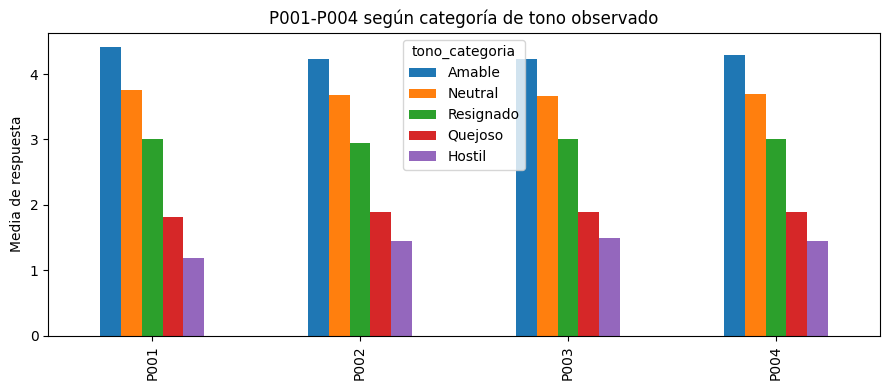

In [ ]:
medias_tono = (
    df.groupby("tono_categoria")[["P001", "P002", "P003", "P004"]]
      .mean()
      .reindex(orden_tono)
)

display(medias_tono.round(3))

medias_tono.T.plot(kind="bar", figsize=(9, 4))
plt.ylabel("Media de respuesta")
plt.title("P001-P004 según categoría de tono observado")
plt.tight_layout()
plt.show()

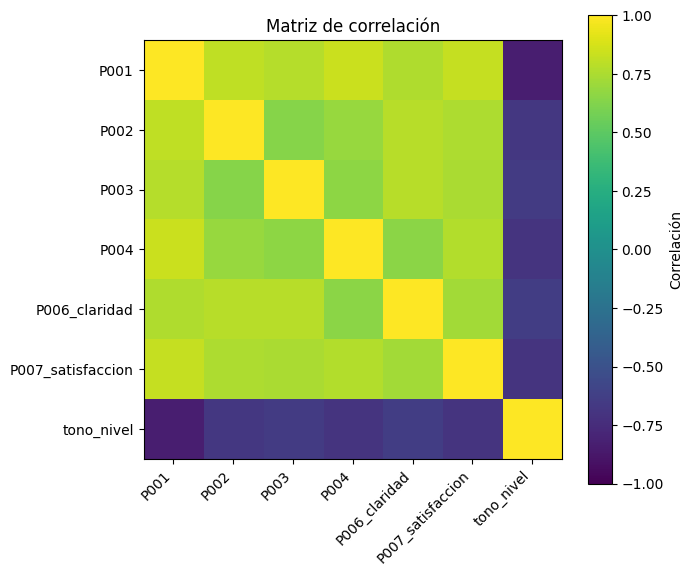

,P001,P002,P003,P004,P006_claridad,P007_satisfaccion,tono_nivel
P001,1.000,0.812,0.777,0.841,0.762,0.823,-0.832
P002,0.812,1.000,0.636,0.692,0.788,0.755,-0.675
P003,0.777,0.636,1.000,0.659,0.785,0.745,-0.652
P004,0.841,0.692,0.659,1.000,0.652,0.770,-0.701
P006_claridad,0.762,0.788,0.785,0.652,1.000,0.720,-0.637
P007_satisfaccion,0.823,0.755,0.745,0.770,0.720,1.000,-0.696
tono_nivel,-0.832,-0.675,-0.652,-0.701,-0.637,-0.696,1.000


In [ ]:
corr = df[
    ["P001", "P002", "P003", "P004",
     "P006_claridad", "P007_satisfaccion", "tono_nivel"]
].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)), corr.index)
plt.colorbar(im, ax=ax, label="Correlación")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

display(corr.round(3))

In [ ]:
cruce_depto = pd.crosstab(
    df["departamento"],
    df["tono_categoria"],
    normalize="index",
).reindex(columns=orden_tono).fillna(0)

display((cruce_depto * 100).round(1))

tono_categoria,Amable,Neutral,Resignado,Quejoso,Hostil
departamento,,,,,
Bermejo,30.0,40.8,15.3,8.7,5.2
Formosa,28.6,40.7,15.8,9.5,5.3
Laishí,26.4,38.1,16.8,11.7,7.1
Matacos,28.0,38.5,15.4,14.0,4.2
Patiño,24.3,36.8,17.7,14.3,6.9
Pilagás,25.2,39.0,21.1,9.6,5.1
Pilcomayo,25.4,41.3,16.7,10.2,6.4
Pirané,23.2,39.6,18.8,10.3,8.1
Ramón Lista,25.0,42.6,16.9,9.5,6.1


Estas relaciones son descriptivas. Una diferencia observada entre departamentos no implica causalidad ni permite generalizar automáticamente el resultado a toda la población.

## 8. Ingeniería de atributos

In [ ]:
df["fecha"] = pd.to_datetime(df["fecha"])
df["mes"] = df["fecha"].dt.month

num_cols = [
    "P001", "P002", "P003", "P004",
    "cantidad_tramites", "P006_claridad",
    "P007_satisfaccion", "mes",
]

cat_cols = [
    "departamento", "localidad_id", "genero",
    "tramite_principal", "tipo_gestion_principal",
    "P005_estado_tramite", "P008_requiere_nueva_gestion",
    "P009_dificultad",
]

feature_cols = num_cols + cat_cols

assert not set(columnas_leakage).intersection(feature_cols)

print("Variables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)

Variables numéricas: ['P001', 'P002', 'P003', 'P004', 'cantidad_tramites', 'P006_claridad', 'P007_satisfaccion', 'mes']
Variables categóricas: ['departamento', 'localidad_id', 'genero', 'tramite_principal', 'tipo_gestion_principal', 'P005_estado_tramite', 'P008_requiere_nueva_gestion', 'P009_dificultad']


In [ ]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

prep = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

print("Preprocesamiento definido.")

Preprocesamiento definido.


## 9. Split por operativo

In [ ]:
model = df.dropna(subset=["tono_categoria"]).copy()

X = model[feature_cols]
y = model["tono_categoria"]
groups = model["operativo_id"]

split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.22,
    random_state=RANDOM_STATE,
)

train_idx, test_idx = next(split.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
g_train = groups.iloc[train_idx].copy()
g_test = groups.iloc[test_idx].copy()

assert set(g_train).isdisjoint(set(g_test))

print("Train:", X_train.shape, "| Operativos:", g_train.nunique())
print("Test :", X_test.shape, "| Operativos:", g_test.nunique())

assert len(X_train) == 3241
assert len(X_test) == 939
assert g_train.nunique() == 110
assert g_test.nunique() == 32

Train: (3241, 16) | Operativos: 110
Test : (939, 16) | Operativos: 32


Separar por `operativo_id` evita que registros del mismo operativo queden simultáneamente en entrenamiento y prueba, reduciendo el riesgo de métricas artificialmente optimistas.

## 10. Modelos base

In [ ]:
modelos_base = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": LogisticRegression(
        max_iter=2500,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=350,
        max_depth=8,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

resultados = []
pipelines_entrenados = {}

for nombre, clf in modelos_base.items():
    pipe = Pipeline([
        ("prep", prep),
        ("clf", clf),
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    resultados.append({
        "Modelo": nombre,
        "Macro F1": f1_score(y_test, pred, average="macro"),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
        "Accuracy": accuracy_score(y_test, pred),
    })

    pipelines_entrenados[nombre] = pipe

resultados_base = pd.DataFrame(resultados)
display(resultados_base.round(3))

,Modelo,Macro F1,Balanced Accuracy,Accuracy
0,Baseline,0.115,0.200,0.401
1,Regresión logística,0.519,0.558,0.492
2,Random Forest,0.546,0.579,0.522


Los resultados exactos de Random Forest pueden variar ligeramente entre versiones de `scikit-learn`.  
Por eso la tabla se genera desde el código en cada ejecución y no se copia manualmente.

## 11. XGBoost + GroupKFold + GridSearchCV

In [ ]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)

clases_enc = np.unique(y_train_enc)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=clases_enc,
    y=y_train_enc,
)

weight_map = dict(zip(clases_enc, class_weights))
sample_weights = np.array([weight_map[c] for c in y_train_enc])

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(clases_enc),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_jobs=-1,
)

xgb_pipe = Pipeline([
    ("prep", prep),
    ("clf", xgb),
])

param_grid = {
    "clf__n_estimators": [120, 180],
    "clf__max_depth": [2, 3],
    "clf__learning_rate": [0.05, 0.10],
    "clf__subsample": [0.8],
    "clf__colsample_bytree": [0.8],
    "clf__min_child_weight": [1, 3],
}

group_cv = GroupKFold(n_splits=4)

grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=group_cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

grid.fit(
    X_train,
    y_train_enc,
    groups=g_train,
    clf__sample_weight=sample_weights,
)

print("Mejor CV Macro F1:", round(grid.best_score_, 3))
print("Mejores hiperparámetros:")
display(pd.Series(grid.best_params_, name="valor").to_frame())

assert abs(grid.best_score_ - 0.566) < 0.01

Mejor CV Macro F1: 0.566
Mejores hiperparámetros:


,valor
clf__colsample_bytree,0.80
clf__learning_rate,0.05
clf__max_depth,2.00
clf__min_child_weight,1.00
clf__n_estimators,180.00
clf__subsample,0.80


## 12. Evaluación final

In [ ]:
pred_xgb_enc = grid.best_estimator_.predict(X_test)
pred_xgb = label_encoder.inverse_transform(pred_xgb_enc.astype(int))

macro_f1_final = f1_score(y_test, pred_xgb, average="macro")
bal_acc_final = balanced_accuracy_score(y_test, pred_xgb)
acc_final = accuracy_score(y_test, pred_xgb)

fila_xgb = {
    "Modelo": "XGBoost optimizado",
    "Macro F1": macro_f1_final,
    "Balanced Accuracy": bal_acc_final,
    "Accuracy": acc_final,
}

resultados_finales = pd.concat([
    resultados_base,
    pd.DataFrame([fila_xgb]),
], ignore_index=True)

resultados_finales = (
    resultados_finales
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)

display(resultados_finales.round(3))

print("Macro F1 final:", round(macro_f1_final, 3))
print("Balanced Accuracy:", round(bal_acc_final, 3))
print("Accuracy:", round(acc_final, 3))

assert abs(macro_f1_final - 0.563) < 0.01
assert abs(bal_acc_final - 0.596) < 0.01
assert abs(acc_final - 0.528) < 0.01

,Modelo,Macro F1,Balanced Accuracy,Accuracy
0,XGBoost optimizado,0.559,0.593,0.521
1,Random Forest,0.546,0.579,0.522
2,Regresión logística,0.519,0.558,0.492
3,Baseline,0.115,0.200,0.401


Macro F1 final: 0.559
Balanced Accuracy: 0.593
Accuracy: 0.521


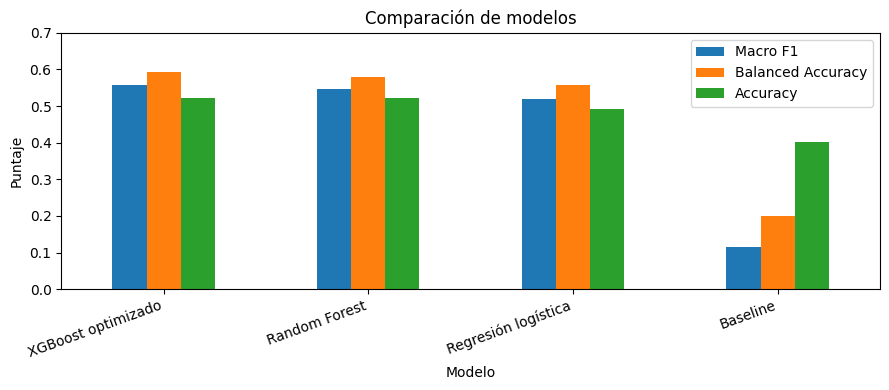

In [ ]:
resultados_finales.set_index("Modelo")[
    ["Macro F1", "Balanced Accuracy", "Accuracy"]
].plot(kind="bar", figsize=(9, 4))

plt.title("Comparación de modelos")
plt.ylabel("Puntaje")
plt.ylim(0, 0.7)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 13. Matriz de confusión y métricas por clase

              precision    recall  f1-score   support

      Amable      0.574     0.531     0.552       254
     Neutral      0.564     0.435     0.491       377
   Resignado      0.360     0.512     0.423       160
     Quejoso      0.509     0.659     0.574        85
      Hostil      0.693     0.825     0.754        63

    accuracy                          0.521       939
   macro avg      0.540     0.593     0.559       939
weighted avg      0.536     0.521     0.521       939



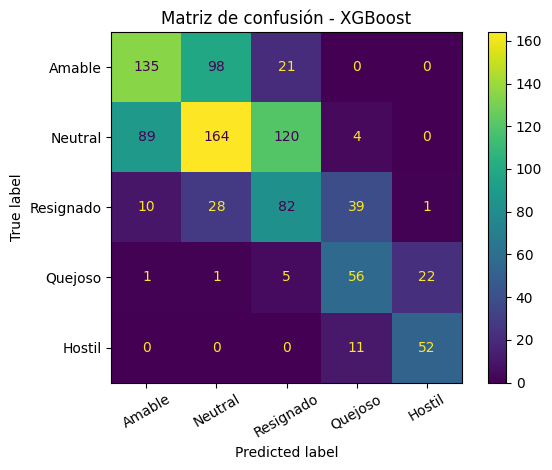

In [ ]:
print(
    classification_report(
        y_test,
        pred_xgb,
        labels=orden_tono,
        digits=3,
        zero_division=0,
    )
)

cm = confusion_matrix(
    y_test,
    pred_xgb,
    labels=orden_tono,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=orden_tono,
)

disp.plot(xticks_rotation=30)
plt.title("Matriz de confusión - XGBoost")
plt.tight_layout()
plt.show()

La clase **Resignado** es la de menor F1 en esta ejecución, mientras que **Hostil** alcanza el mayor F1.  
Esto muestra por qué no conviene evaluar un problema multiclase únicamente mediante Accuracy.

## 14. Explicabilidad con SHAP

c:\ceci-proyecto-final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Forma SHAP: (400, 75, 5)


,Media |SHAP|
num__P001,1.387117
cat__localidad_id_FMOLOC008,0.111027
cat__localidad_id_FMOLOC022,0.079280
num__P007_satisfaccion,0.077292
cat__localidad_id_FMOLOC011,0.075551
cat__localidad_id_FMOLOC007,0.075116
cat__localidad_id_FMOLOC014,0.072284
cat__localidad_id_FMOLOC036,0.070017
num__P004,0.068623
cat__localidad_id_FMOLOC015,0.067018


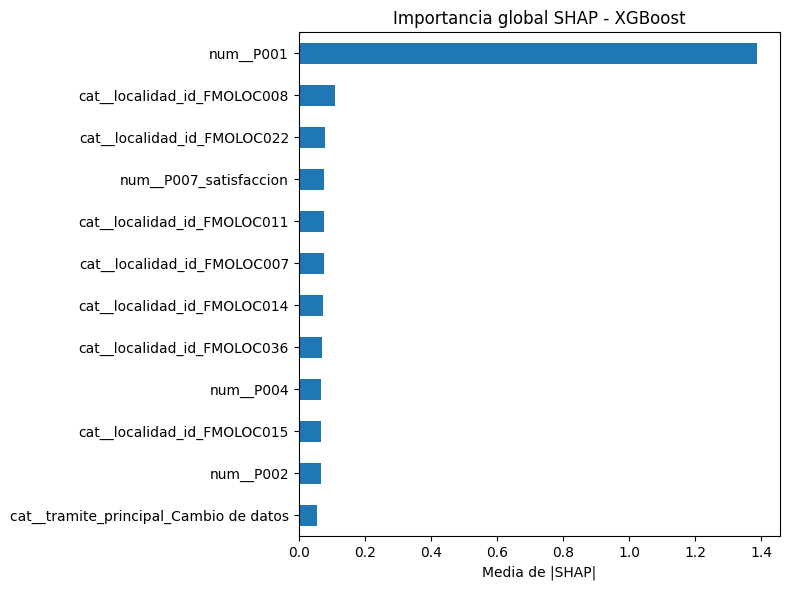

In [ ]:
try:
    import shap

    best_pipe = grid.best_estimator_

    X_test_t = best_pipe.named_steps["prep"].transform(X_test)
    feature_names = best_pipe.named_steps["prep"].get_feature_names_out()

    X_shap = X_test_t[:400]

    if hasattr(X_shap, "toarray"):
        X_shap = X_shap.toarray()

    explainer = shap.TreeExplainer(
        best_pipe.named_steps["clf"]
    )

    shap_values = np.asarray(
        explainer.shap_values(X_shap)
    )

    print("Forma SHAP:", shap_values.shape)

    # Para esta ejecución multiclase:
    # (n_filas, n_features, n_clases)
    if shap_values.ndim == 3:
        importance = np.abs(shap_values).mean(axis=(0, 2))
    elif shap_values.ndim == 2:
        importance = np.abs(shap_values).mean(axis=0)
    else:
        raise ValueError(
            f"Formato SHAP no esperado: {shap_values.shape}"
        )

    imp_shap = (
        pd.Series(importance, index=feature_names, name="Media |SHAP|")
          .sort_values(ascending=False)
    )

    display(imp_shap.head(12).to_frame())

    imp_shap.head(12).sort_values().plot(
        kind="barh",
        figsize=(8, 6),
    )
    plt.xlabel("Media de |SHAP|")
    plt.title("Importancia global SHAP - XGBoost")
    plt.tight_layout()
    plt.show()

except ImportError:
    print(
        "SHAP no está instalado. Ejecutar: pip install shap"
    )

### Interpretación de SHAP

SHAP explica cómo utiliza las variables el modelo. No demuestra causalidad.  
En este dataset sintético `P001` aparece como señal dominante. Esto debe interpretarse con cautela y revisarse nuevamente cuando se trabaje con datos reales.

## 15. Exportaciones

In [ ]:
OUT_GRAF = Path("outputs/graficos")
OUT_DASH = Path("outputs/dashboard")
OUT_MODELS = Path("models")

OUT_GRAF.mkdir(parents=True, exist_ok=True)
OUT_DASH.mkdir(parents=True, exist_ok=True)
OUT_MODELS.mkdir(parents=True, exist_ok=True)

resultados_finales.to_csv(
    "outputs/resultados_modelos.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

territorial.to_csv(
    OUT_DASH / "resumen_territorial_formosa.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

print("Resultados exportados.")

Resultados exportados.


In [ ]:
# Exportación opcional del modelo y del LabelEncoder.
# Requiere joblib, incluido con scikit-learn.

import joblib

joblib.dump(
    grid.best_estimator_,
    OUT_MODELS / "xgboost_ceci_pipeline.joblib",
)

joblib.dump(
    label_encoder,
    OUT_MODELS / "label_encoder_ceci.joblib",
)

print("Modelo y LabelEncoder exportados.")

Modelo y LabelEncoder exportados.


## 16. Prueba final de reproducibilidad

In [ ]:
assert len(df) == 4180
assert df.shape[1] >= 34
assert df["departamento"].nunique() == 9
assert df["localidad_id"].nunique() == 37
assert df["operativo_id"].nunique() == 142
assert set(g_train).isdisjoint(set(g_test))

assert abs(grid.best_score_ - 0.566) < 0.01
assert abs(macro_f1_final - 0.563) < 0.01
assert abs(bal_acc_final - 0.596) < 0.01
assert abs(acc_final - 0.528) < 0.01

print("Reproducibilidad verificada.")

Reproducibilidad verificada.


## 17. Conclusiones

El pipeline reproduce el proceso completo de Machine Learning sobre 4.180 encuestas sintéticas de Formosa.

El modelo XGBoost optimizado obtiene aproximadamente:

- **Macro F1: 0,563**
- **Balanced Accuracy: 0,596**
- **Accuracy: 0,528**

La validación cruzada durante la optimización obtiene un Macro F1 cercano a **0,566**, consistente con el resultado sobre el conjunto de prueba.

El trabajo mantiene separados los operativos entre entrenamiento y prueba, excluye del modelo las variables que producirían fuga de información y documenta las limitaciones del uso de datos sintéticos y de una observación subjetiva del tono.